In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits

import scipy as sp
from PIL import Image
from rembg import remove

import scipy as sp

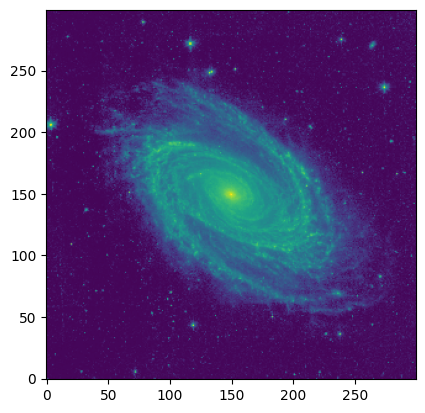

In [26]:
img = np.array(Image.open("background_spiral.jpg"))

img_grey = img[...,1]
img_grey = img_grey / img_grey.max()

img_zoomed = sp.ndimage.zoom(img_grey, 0.2)

plt.imshow(img_zoomed, origin='lower')
plt.show()

In [56]:
def compute_ellipticity(q, phi):
    e = (1 - q) / (1 + q)
    e1 = e * np.cos(2 * phi)
    e2 = e * np.sin(2 * phi)
    return e1, e2


def gaussian_ellipse(x, y, params=np.array([0,0,0,0,0])):
    """
    2D elliptical Gaussian.

    Parameters
    ----------
    x, y : 2D arrays
        Meshgrid coordinates.
    x0, y0 : float
        Centre of the Gaussian.
    phi : float
        Rotation angle (radians), CCW from x-axis.
    q : float
        Axis ratio b/a (0 < q <= 1).
    sigma : float
        Major-axis Gaussian width.
    amp : float
        Amplitude.

    Returns
    -------
    I : 2D array
        Elliptical Gaussian evaluated on (x, y).
    """
    x0, y0, phi, q, sigma = params

    # shift
    xp = x - x0
    yp = y - y0

    # rotate coordinates
    cos_phi = np.cos(phi)
    sin_phi = np.sin(phi)

    x_rot =  cos_phi * xp + sin_phi * yp
    y_rot = -sin_phi * xp + cos_phi * yp

    # elliptical radius
    r2 = (x_rot**2 + (y_rot**2) / q**2) / sigma**2

    return np.exp(-0.5 * r2)


In [62]:
from itertools import product
import numpy as np

# Your parameter grids
phi = np.array([0])
q = np.array([1])
sigma = np.linspace(10, 80, 20)

y, x = img_zoomed.shape
X, Y = np.meshgrid(np.arange(x), np.arange(y))

best_params = None
min_diff = np.inf

for p_x, p_y, p_phi, p_q, p_sigma in product(np.linspace(0, x, 20), np.linspace(0, y, 20), phi, q, sigma):
    params = (p_x, p_y, p_phi, p_q, p_sigma)
    
    gauss = gaussian_ellipse(x=X, y=Y, params=params)
    
    diff = np.sum((gauss - img_zoomed) ** 2)
    
    if diff < min_diff:
        min_diff = diff
        best_params = params

print("Best params:", best_params)
print("Min difference:", min_diff)


Best params: (np.float64(157.89473684210526), np.float64(142.10526315789474), np.int64(0), np.int64(1), np.float64(39.473684210526315))
Min difference: 1089.7527166575


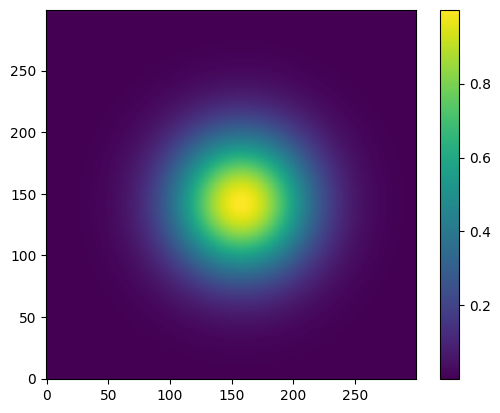

In [63]:
gauss = gaussian_ellipse(X, Y, params=best_params)
plt.imshow(gauss, origin='lower')
plt.colorbar()
plt.show()

In [110]:
%matplotlib inline
import matplotlib.pyplot as plt

In [111]:
euclid_deep = np.array(Image.open("data/euclid_deep_zoom.jpg"))
euclid_deep_VIS = euclid_deep.copy()[...,2]

FileNotFoundError: [Errno 2] No such file or directory: 'data/euclid_deep_zoom.jpg'

In [ ]:
GALAXIES = {
    0: (688, 1646),
    1: (1797, 1807)
}

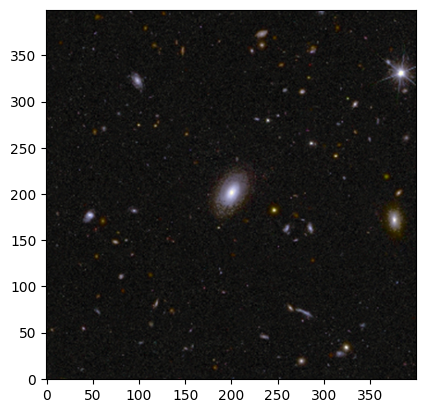

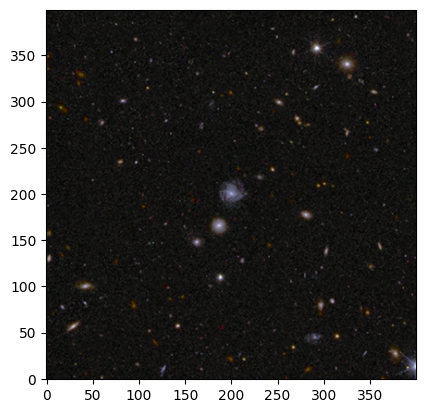

In [ ]:
d=200

for i in range(0,2):
    x,y = GALAXIES[i]
    plt.imshow(euclid_deep[y-d:y+d, x-d:x+d], origin='lower')
    plt.show()    


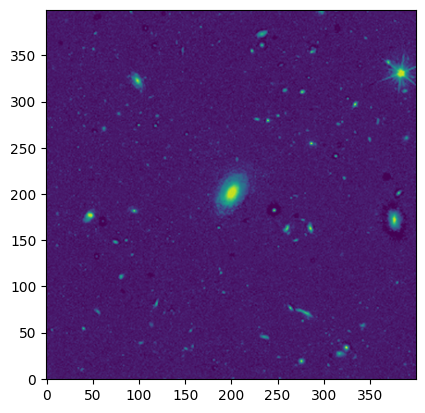

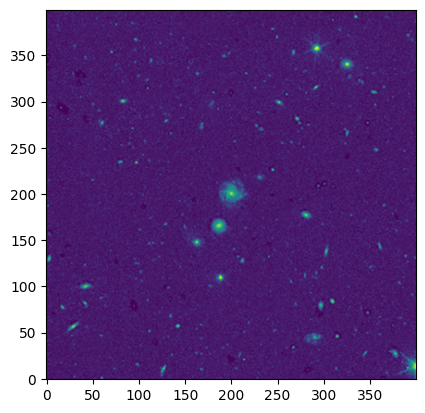

In [ ]:
d=200
galaxy_images = []
for i in range(0,2):
    x,y = GALAXIES[i]
    plt.imshow(euclid_deep_VIS[y-d:y+d, x-d:x+d], origin='lower')
    plt.show()    

    galaxy_images.append(euclid_deep_VIS[y-d:y+d, x-d:x+d])

In [ ]:
g2 = np.array(galaxy_images[1])

sigma = np.std(g2)
print(sigma)
g2_no_noise = g2.copy()
g2_no_noise[g2_no_noise < 3*sigma] = 0


12.074360173912943


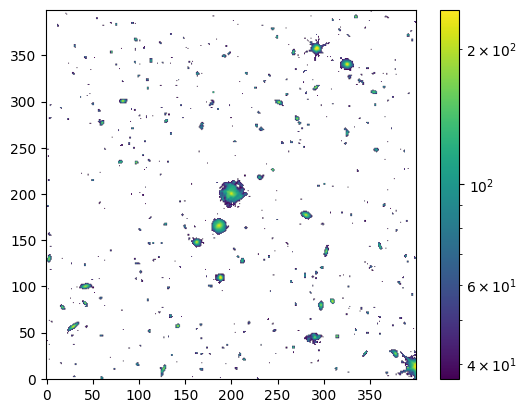

In [ ]:
plt.imshow(g2_no_noise, origin='lower', norm='log')
plt.colorbar()
plt.show()

In [ ]:
np.save("data/euclid_deep_VIS2.npy", g2_no_noise)

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from scipy.integrate import quad
from scipy.interpolate import CubicSpline

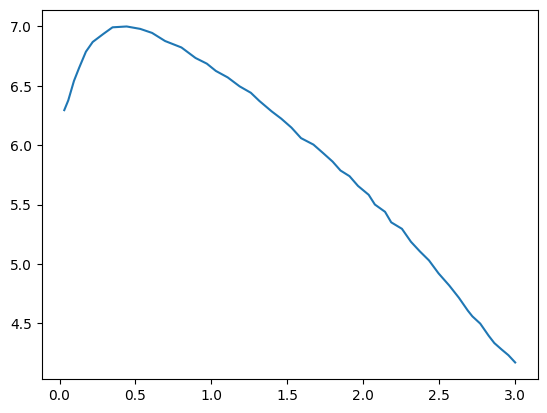

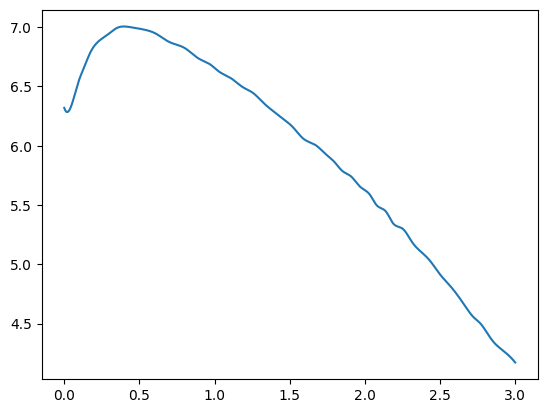

In [113]:
df = pd.read_csv("distribution.csv")

curve = np.array(df.values)
curve_sorted = curve[curve[:, 0].argsort()]

x = curve_sorted[:, 0] * 3
y = curve_sorted[:, 1] / np.max(curve_sorted[:, 1]) * 3 + 4

plt.plot(x, y)
plt.show()

distribution = np.stack([x,y], axis=1)

np.save("theta_distribution.npy", distribution)

interp = CubicSpline(x=distribution[:,0],y=distribution[:,1])

x_vals = np.linspace(0, 3, 10000)
y_vals = [interp(x) for x in x_vals]

plt.plot(x_vals, y_vals)
plt.show()



In [ ]:
I = interp.integrate(0.0, 3.0)

In [ ]:
print(I)

17.890736930186016


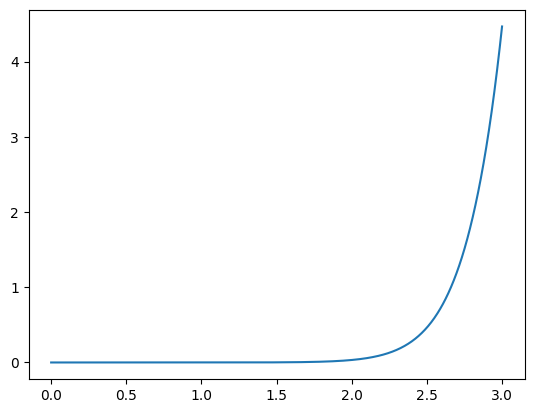

In [114]:
import numpy as np
from scipy.integrate import cumulative_trapezoid, trapezoid

# define theta grid
theta = np.linspace(0, 3, 1000)

# your derivative of log n(theta)
def g(theta):
    interp = CubicSpline(x=distribution[:,0],y=distribution[:,1])
    return interp(theta)  

g_vals = g(theta)

# integrate g(theta) to get log n(theta)
logn = cumulative_trapezoid(g_vals, theta, initial=0.0)

# exponentiate
n = np.exp(logn)

# normalize to get pdf
Z = trapezoid(n, theta)
pdf = n / Z

plt.plot(theta, pdf)
plt.show()


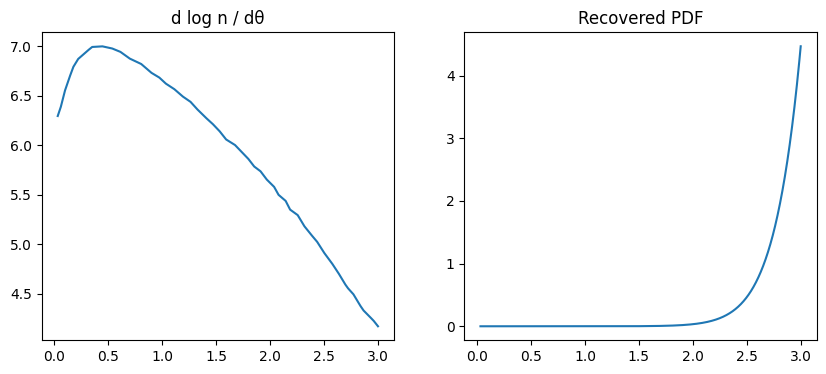

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.interpolate import interp1d


df = pd.read_csv("distribution.csv")

curve = np.array(df.values)
curve_sorted = curve[curve[:, 0].argsort()]

x = curve_sorted[:, 0] * 3
y = curve_sorted[:, 1] / np.max(curve_sorted[:, 1]) * 3 + 4

distribution = np.stack([x,y], axis=1)


theta = np.linspace(distribution[:,0].min(), distribution[:,0].max(), 10_000)
interp = interp1d(
    distribution[:,0],
    distribution[:,1],
    kind='linear',
    bounds_error=False,
    fill_value=(distribution[0,1], distribution[-1,1])
)

g_vals = interp(theta)

logn = cumulative_trapezoid(g_vals, theta, initial=0.0)

n = np.exp(logn)
pdf = n / trapezoid(n, theta)


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(theta, g_vals)
plt.title("d log n / dθ")

plt.subplot(1,2,2)
plt.plot(theta, pdf)
plt.title("Recovered PDF")

plt.show()

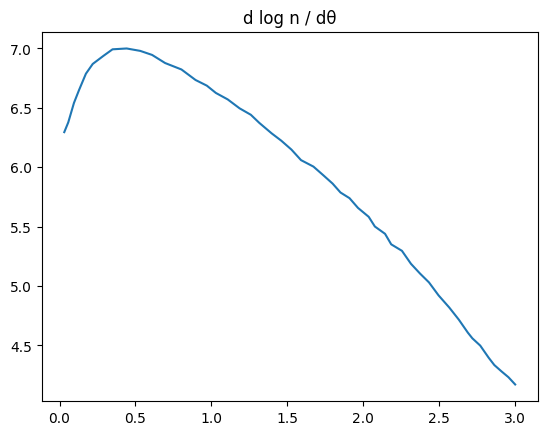

max: 7.0 min: 4.1708103312859865


In [ ]:
plt.plot(distribution[:,0], distribution[:,1])
plt.title("d log n / dθ")
plt.show()
print("max:", np.max(distribution[:,1]), "min:", np.min(distribution[:,1]))


In [ ]:
import numpy as np

# Example: theta grid and dlogN/dtheta values
theta = np.linspace(0.1, 3, 1000)  # replace with your theta
dlogN_dtheta = interp(theta)      # replace with your actual data

# Step 1: Integrate dlogN/dtheta to get logN (cumulative)
logN = np.cumsum(dlogN_dtheta * np.gradient(theta))  # approximate integral

# Step 2: Convert to linear scale
N_theta = 10**logN

# Step 3: Normalize to get PDF
pdf = N_theta / np.trapezoid(N_theta, theta)

# pdf is now a normalized PDF over theta


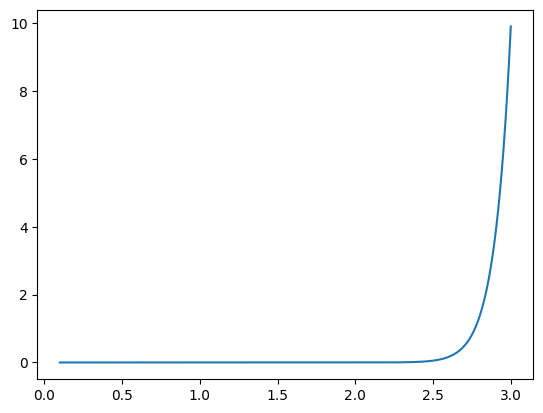

In [ ]:
plt.plot(theta, pdf)
plt.show()

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [72]:
df = pd.read_csv("modeling_lens_mass.csv")
df.head()

,Unnamed: 0,id_str,einstein_radius_effective_max_lh,einstein_radius_effective_median_pdf,einstein_radius_effective_lower_1_sigma,einstein_radius_effective_upper_1_sigma,einstein_radius_effective_lower_3_sigma,einstein_radius_effective_upper_3_sigma,centre_0_max_lh,centre_0_median_pdf,...,shear_gamma_1_lower_3_sigma,shear_gamma_1_upper_3_sigma,shear_gamma_1_lower_1_sigma,shear_gamma_1_upper_1_sigma,shear_gamma_2_max_lh,shear_gamma_2_median_pdf,shear_gamma_2_lower_3_sigma,shear_gamma_2_upper_3_sigma,shear_gamma_2_lower_1_sigma,shear_gamma_2_upper_1_sigma
0,0,102018665_NEG570040238507752998,0.853124,0.820237,0.790856,0.851182,0.773844,0.859449,-0.096528,-0.080179,...,-0.215621,0.026464,-0.161777,-0.052136,-0.028271,0.007414,-0.090688,0.129944,-0.026798,0.061116
1,1,102018665_NEG576731213511114485,0.987852,0.988056,0.983574,0.994458,0.973808,1.001143,-0.053157,-0.049730,...,0.078293,0.179014,0.125748,0.148589,-0.059590,-0.062631,-0.103176,-0.019012,-0.072831,-0.051687
2,2,102018666_NEG579859279508531437,1.510350,1.514415,1.509662,1.518703,1.498638,1.534338,-0.033898,-0.054047,...,-0.099939,-0.034521,-0.078691,-0.062894,-0.002803,0.010481,-0.028563,0.054750,-0.000171,0.023489
3,3,102018667_NEG587746535508057234,0.888685,0.883230,0.870709,0.892765,0.870709,0.899503,0.106716,0.102090,...,-0.020033,0.030900,-0.007490,0.011127,-0.104615,-0.075370,-0.137553,-0.062196,-0.116377,-0.071797
4,4,102018668_NEG595646727509469177,0.453341,0.456494,0.450868,0.462993,0.446139,0.468314,0.133636,0.137100,...,0.011714,0.082651,0.028079,0.053614,0.086536,0.078113,0.023649,0.127736,0.062040,0.093941


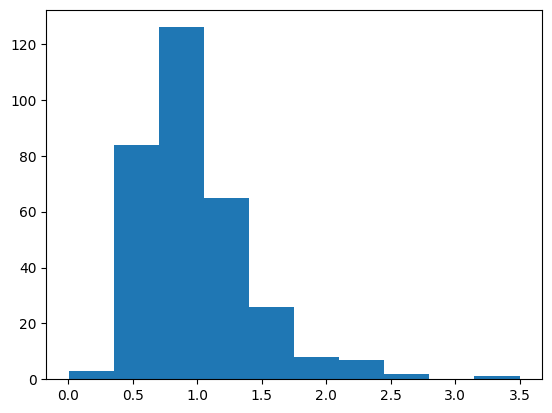

In [97]:
theta = np.array(df["einstein_radius_median_pdf"])
plt.hist(theta, bins=10)
plt.show()

0.9679776159053595
0.42850251392239913


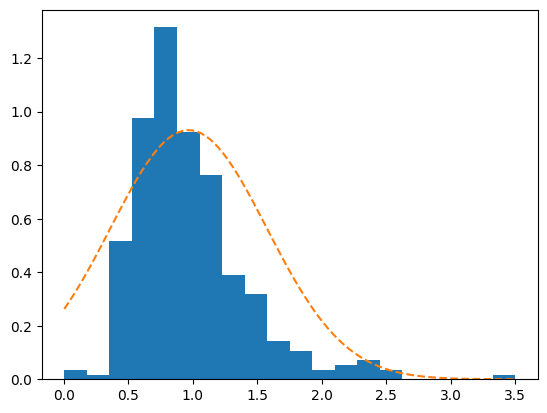

In [102]:
mu = np.nanmean(theta)
sigma = np.nanstd(theta)

print(mu)
print(sigma)

theta_x = np.linspace(np.nanmin(theta), np.nanmax(theta), 100)
n_y = 1 / (sigma * np.sqrt(2*np.pi)) * np.exp(- ((theta_x - mu) / (2 * sigma))**2 )


plt.hist(theta, bins=20, density=True)
plt.plot(theta_x, n_y, '--')
plt.show()


In [3]:
import astropy
import astroquery
from astroquery.esa.euclid import Euclid

In [5]:
Euclid.login(user="oredhead", password=".XzvGw5#rhWDstG")

INFO: Login to Euclid TAP server: eas.esac.esa.int:443/tap-server/tap/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid data service: eas.esac.esa.int:443/sas-dd/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid cutout service: eas.esac.esa.int:443/sas-cutout/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]


In [ ]:
tables = Euclid.launch_job(
    query="",
    name=None,
    dump_to_file=True,
    output_file="euclid_query.csv",
    output_format="csv",
    
)

AttributeError: 'EuclidClass' object has no attribute 'list_tables'